In [1]:
# Imports
import utils_plotting
import utils_inverse

%load_ext autoreload
%autoreload 2

### Figure 1: Optimization pipeline overview

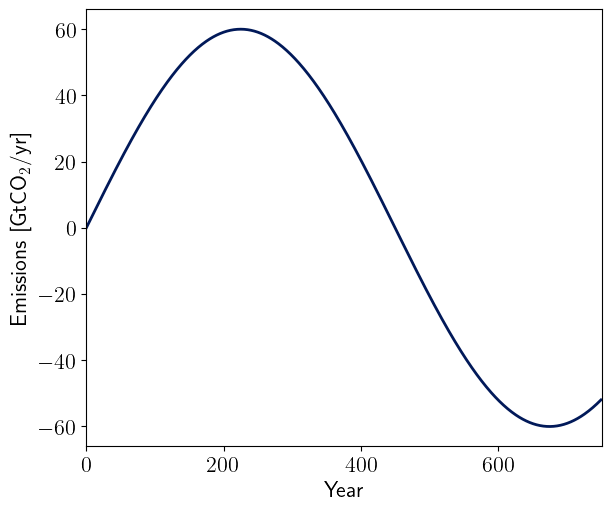

In [2]:
res = utils_inverse.load_inverse_ckpt('checkpoints/co2/inverse_sine_tier1_co2_only.pkl')
utils_plotting.plot_init(res, save=False)

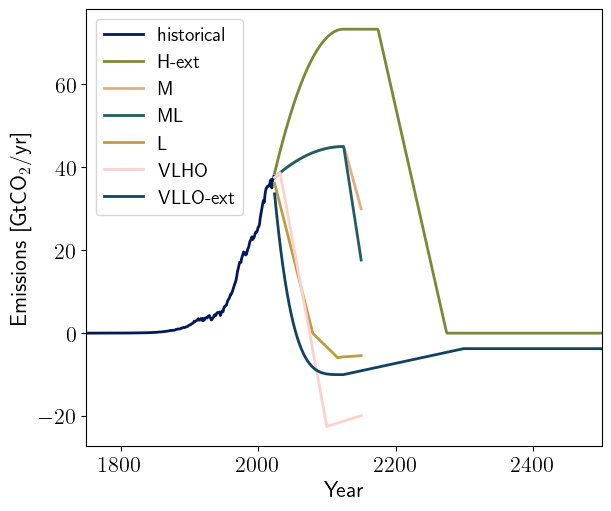

In [3]:
fig1_data = utils_inverse.load_fig1_tier1_scenarios()
utils_plotting.plot_tier1(**fig1_data, save=False)

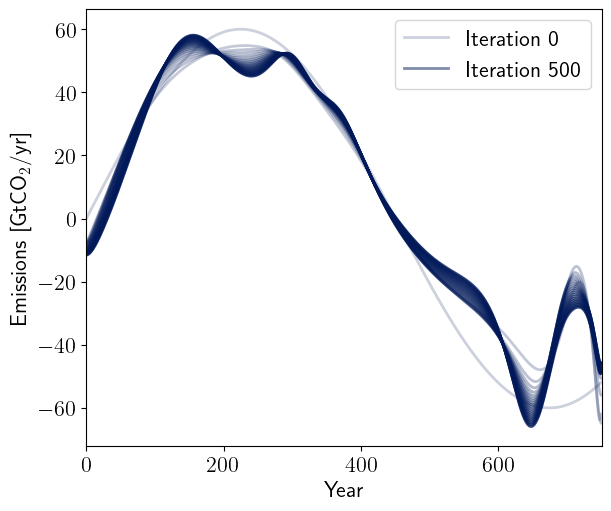

In [4]:
utils_plotting.plot_updates(res, save=False)

### Figure 2: Optimal emissions profile across different optimization targets

In [5]:
fig2_data = utils_inverse.load_fig2_data()

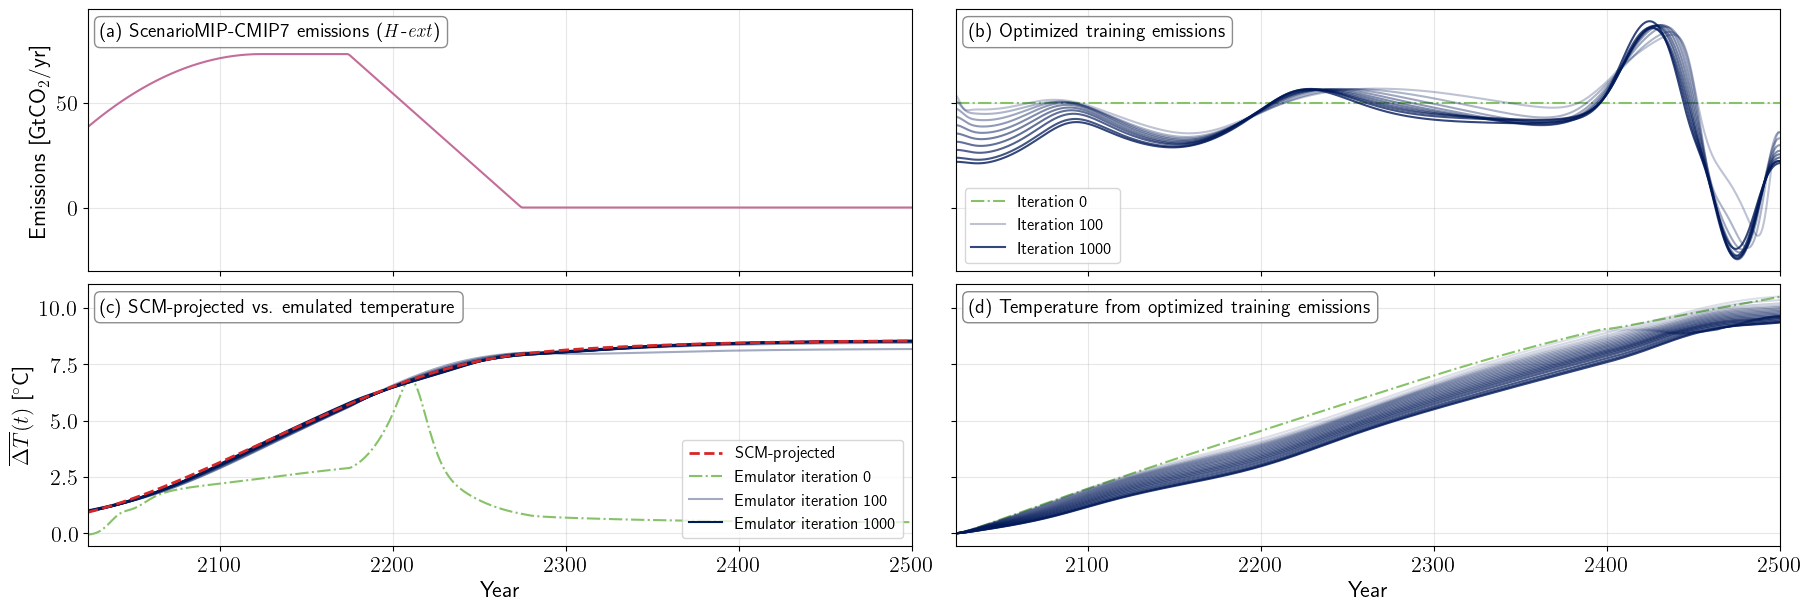

In [6]:
utils_plotting.plot_stacked_results(fig2_data['target_emissions'], fig2_data['years'],
                                     fig2_data['opt_emissions'], fig2_data['opt_temp'], fig2_data['opt_results'],
                                     save=False, save_path='Figures/fig02_co2_example_ppt.pdf')

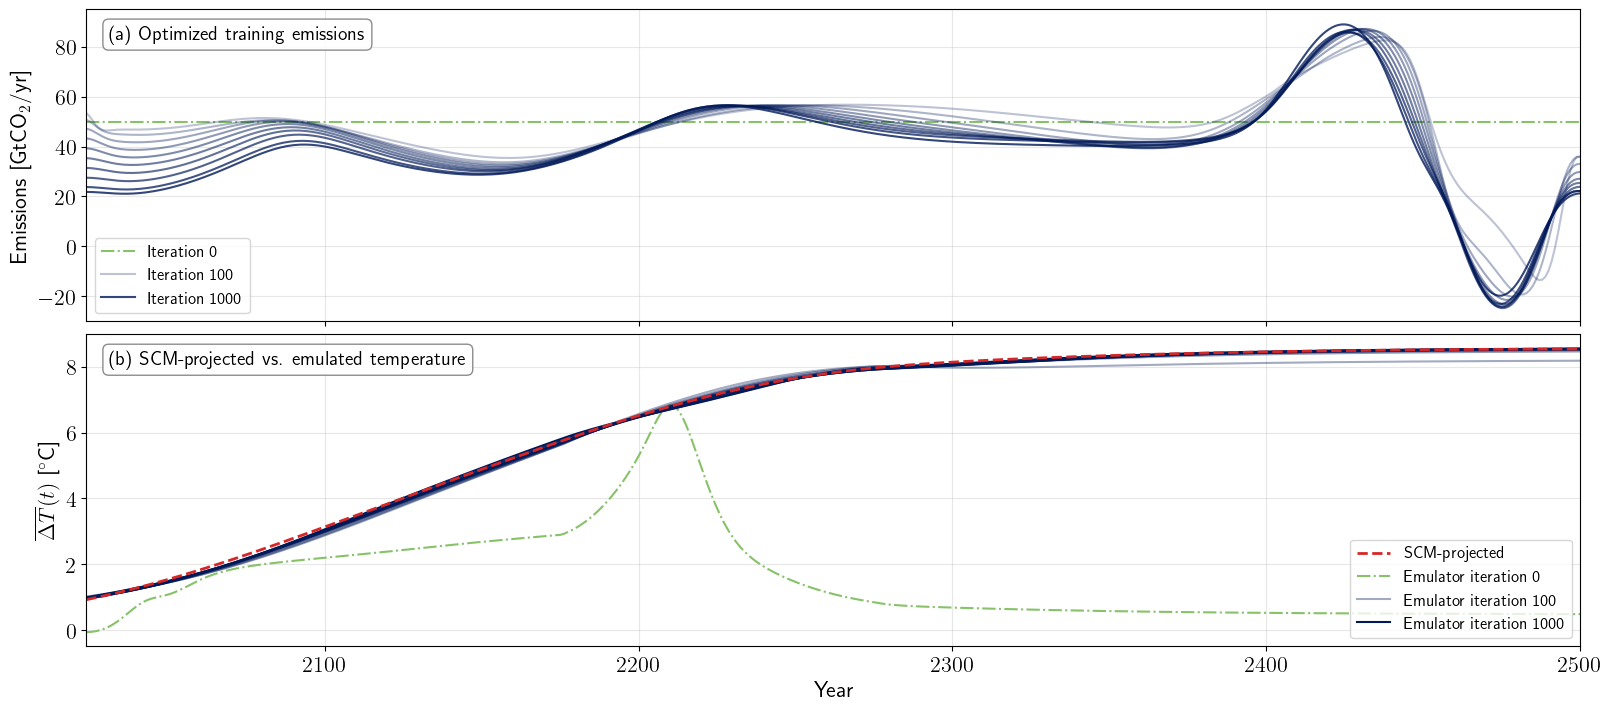

In [7]:
# Plotting w/ Powerpoint friendly aspect ratio
utils_plotting.plot_stacked_results_ppt(fig2_data['years'], fig2_data['opt_emissions'], fig2_data['opt_results'],
                                         save=False, save_path='Figures/fig02_co2_example_ppt_4.pdf')

### Figure 3: RMSE comparison across single-forcing experiments

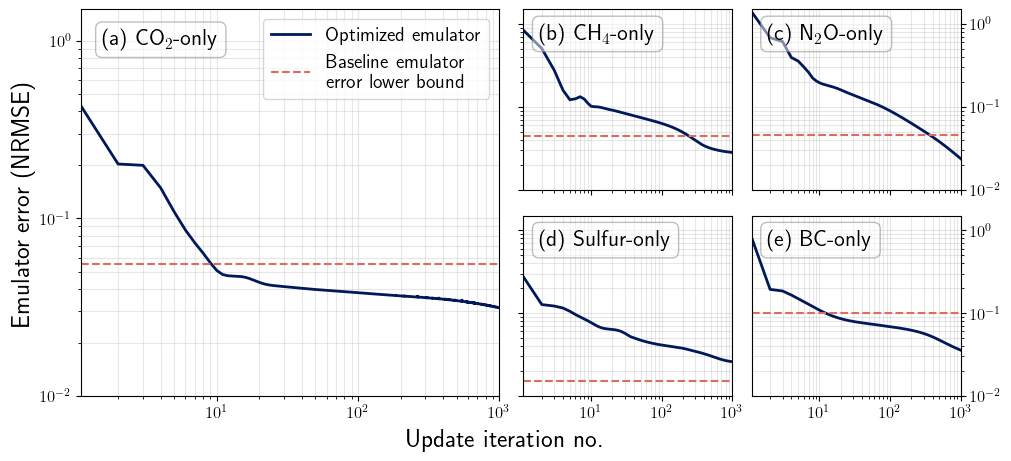

In [8]:
fig3_data = utils_inverse.load_fig3_single_forcing_data()
utils_plotting.plot_rmse_comparison_single(fig3_data['results_inverse'], fig3_data['results_baseline'],
                                            fig3_data['labels'], save=False)

#### Figure 3 with seed-uncertainty spread (2026-08-12, Phase 0 extended to CH4/N2O/Sulfur/BC)

Supersedes the cell above for reporting purposes (left untouched, for comparison). Each panel's
line becomes a mean trajectory across seeds with a shaded min-max band (not mean +/- std - NRMSE
is non-negative and the y-axis is log-scaled, so a std-based lower bound could go non-positive),
reading each agent's `tier1`-group `errors` trajectory across every seed in
`checkpoints/{agent}_retuned/seed_sweep/` (50 seeds, written by
`scripts/0c_regenerate_checkpoints_co2.py` for CO2 and `scripts/0c_regenerate_checkpoints_agent.py
--agent X` for CH4/N2O/Sulfur/BC). Raises `FileNotFoundError` naming the missing agent/seed if any
agent's checkpoints aren't regenerated yet, rather than silently mixing seeded and single-run panels.

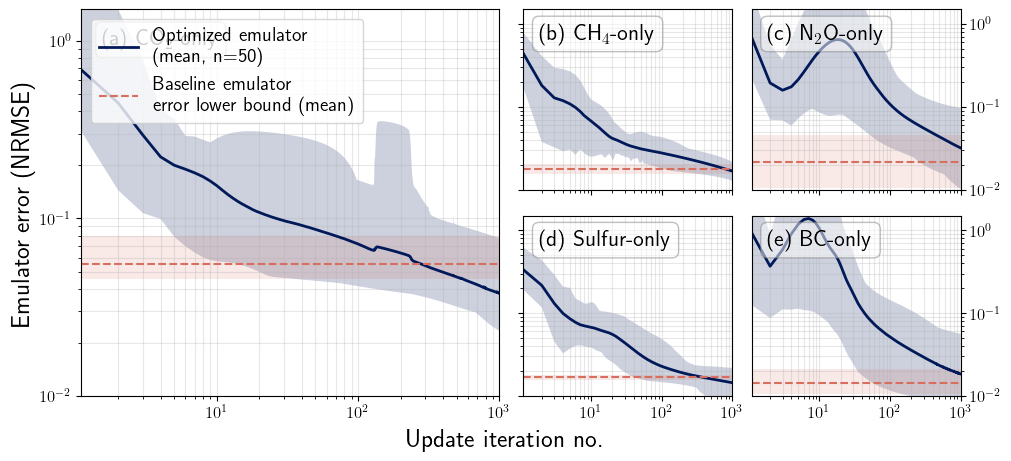

In [9]:
fig3_seed_data = utils_inverse.load_fig3_single_forcing_data_seed_sweep()
utils_plotting.plot_rmse_comparison_single(
    fig3_data['results_inverse'], fig3_data['results_baseline'], fig3_data['labels'],
    seed_errors_list=fig3_seed_data['seed_errors_list'],
    seed_baseline_error_list=fig3_seed_data['seed_baseline_error_list'],
    save=False,
)

### Figure 4: Performance summary across optimization priorities

Reads cached baseline/optimal-emulator NRMSE summaries. To refresh those caches after new
checkpoints are produced upstream, run `python scripts/5a_paper_plots.py --figure 5`.

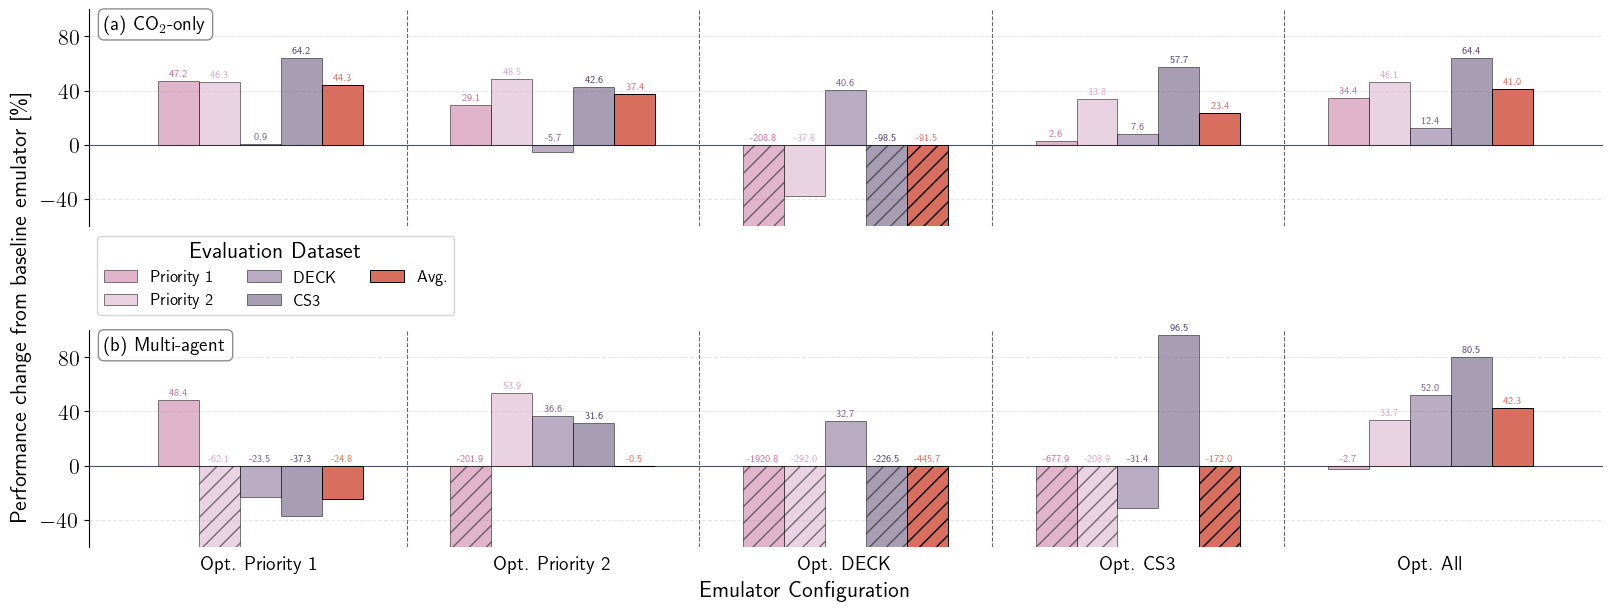

In [10]:
fig4_data = utils_inverse.load_fig4_data()
utils_plotting.plot_vertical_stacked_bars(**fig4_data, titles=None, save=False)

#### Figure 4, CO2-only panel rebuilt on Stage 0c's regenerated checkpoints (2026-08-05)

The cell above still reads the original (stale, pre-Phase-0) `data/plotting/{baseline,optimal}_co2_only.pkl`
cache, left untouched for comparison. This cell reads the new cache built from
`checkpoints/co2_retuned/` (Stage 0b's unified optimizer hyperparameters + Stage 6e's
independently-tuned baseline) via `utils_inverse.regenerate_fig4_co2_only_cache()` -
CO2-only side only; the multi-agent panel (`baseline_path_all`/`optimal_path_all`) is
unchanged since those checkpoints haven't been regenerated yet.

**2026-08-05 correction (temporary, phase 1 of 2):** the first version of this cache
made the optimized emulator look *worse than baseline* (e.g. CO2-only Tier 1 NRMSE
0.175 vs. baseline ~0.054) - a dramatic reversal from Stage 6e's "gap survives"
conclusion (optimized 0.042 vs. baseline ~0.054-0.056). Root cause: `regenerate_fig4_co2_only_cache`'s
default `ema_windows_years=(5,30,100)` is internally consistent (same value for the
fresh eval-time retrain's train and test features), but does **not** match what actually
produced `checkpoints/co2_retuned/` - `optimize_emissions_inverse` trains on
`ema_windows_years=(5,30,50)` (its own default) but has a *separate, pre-existing* bug
where its own internal test/error tracking always uses `build_valid`'s hardcoded
`(5,30,100)` regardless of what's passed to it (`utils_inverse.py`, `build_valid` call
inside `optimize_emissions_inverse` never forwards `ema_windows_years`). So the
checkpoints were optimized against a train/test-inconsistent objective, and re-evaluating
them with a clean, fully-consistent `(5,30,100)` pipeline exposes how poorly that
inconsistency generalizes - it is not evidence the optimizer regressed.

The cell below now passes `ema_windows_years=(5,30,50)` explicitly, matching what the
checkpoints were actually trained on - confirmed this reproduces Stage 0b/6e's original
numbers almost exactly (CO2-only Tier 1: 0.0465 vs. the 0.0420-0.0455 reported in
`best_config_unified.json` / the gap-persistence check). This is a stopgap so Figure 4
reads correctly for now; **phase 2** (tracked separately) is to fix
`optimize_emissions_inverse`'s `build_valid` call to actually respect its own
`ema_windows_years` parameter, then decide on one canonical EMA convention and re-run
Stage 0b/0c/6e under it.</cell id="cell-13">

Getting gradient for historical...
	||grad BC||: 0.0
	||grad CH4||: 0.0
	||grad CO2||: 0.00018459622515365481
	||grad N2O||: 0.0
	||grad Sulfur||: 0.0


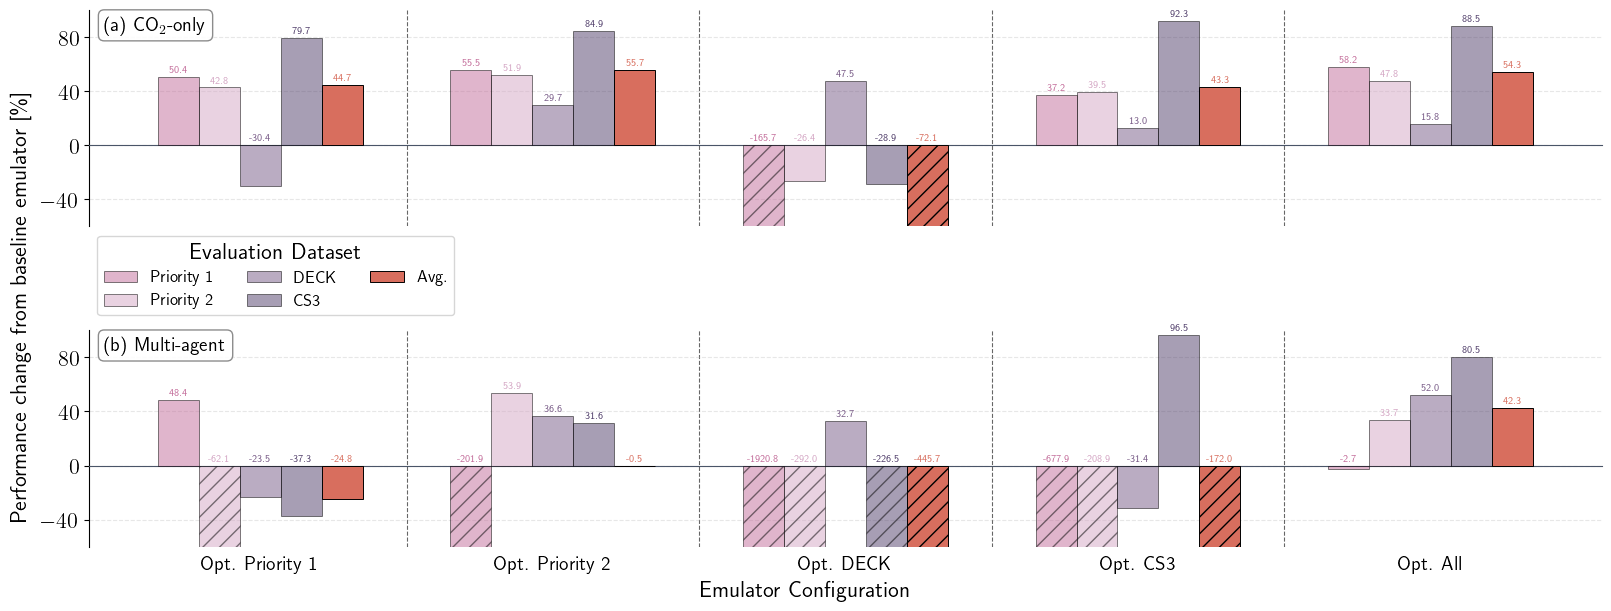

In [11]:
import json

_unified_cfg = json.load(open('data/SI_results/hp_retune/best_config_unified.json'))['config']
_baseline_cfg = json.load(open('data/SI_results/baseline_hp/k400_search/best_baseline_config_K400.json'))['config']

utils_inverse.regenerate_fig4_co2_only_cache(
    checkpoint_dir='checkpoints/co2_retuned',
    baseline_save_path='data/plotting/baseline_co2_only_retuned.pkl',
    optimal_save_path='data/plotting/optimal_co2_only_retuned.pkl',
    K_inner=_unified_cfg['K_inner'], lr_inner=_unified_cfg['lr_inner'], wd_inner=_unified_cfg['wd_inner'],
    baseline_K=_baseline_cfg['K'], baseline_lr=_baseline_cfg['lr'], baseline_weight_decay=_baseline_cfg['weight_decay'],
    ema_windows_years=(5.0, 30.0, 50.0),  # matches what actually trained checkpoints/co2_retuned/ - see markdown above
)

fig4_data_retuned = utils_inverse.load_fig4_data(
    baseline_path_co2='data/plotting/baseline_co2_only_retuned.pkl',
    optimal_path_co2='data/plotting/optimal_co2_only_retuned.pkl',
)
utils_plotting.plot_vertical_stacked_bars(**fig4_data_retuned, titles=None, save=False)

#### Figure 4, CO2-only panel with seed-uncertainty spread (2026-08-10, reviewer Point 1)

Supersedes the cell above for reporting purposes (cells 12-14 are left untouched, for comparison/
history). This reads the fully-corrected pipeline: Stage 0b's hyperparameter search rerun under the
`ema_windows_years` fix (`utils_inverse.py`'s `build_valid` call inside `optimize_emissions_inverse`
now actually forwards its own `ema_windows_years` instead of silently defaulting to `(5,30,100)`),
then Stage 0c's checkpoints regenerated across **50 independent seeds**
(`checkpoints/co2_retuned/seed_sweep/`, `scripts/0c_regenerate_checkpoints_co2.py`), each with its
own independently-trained baseline (not one shared baseline across seeds).

The CO2-only panel shows mean +/- 1 std across the 50 seeds (error bars); the Multi-agent panel is
still the single-point-estimate version, since those checkpoints haven't been multi-seeded yet.
Reads the cached result from `utils_inverse.regenerate_fig4_co2_only_cache_seed_sweep`
(`data/SI_results/seed_uncertainty/fig4_seed_spread_co2_only.pkl`) - generating that cache takes
~4 hours locally (50 seeds x 6 cheap retrains each), so it is **not** regenerated here; see
`6a_seed_uncertainty_sweep.ipynb`'s Figure 4 section for the (commented-out-by-default) generation
cell and instructions for running it as a standalone background script if it ever needs refreshing.

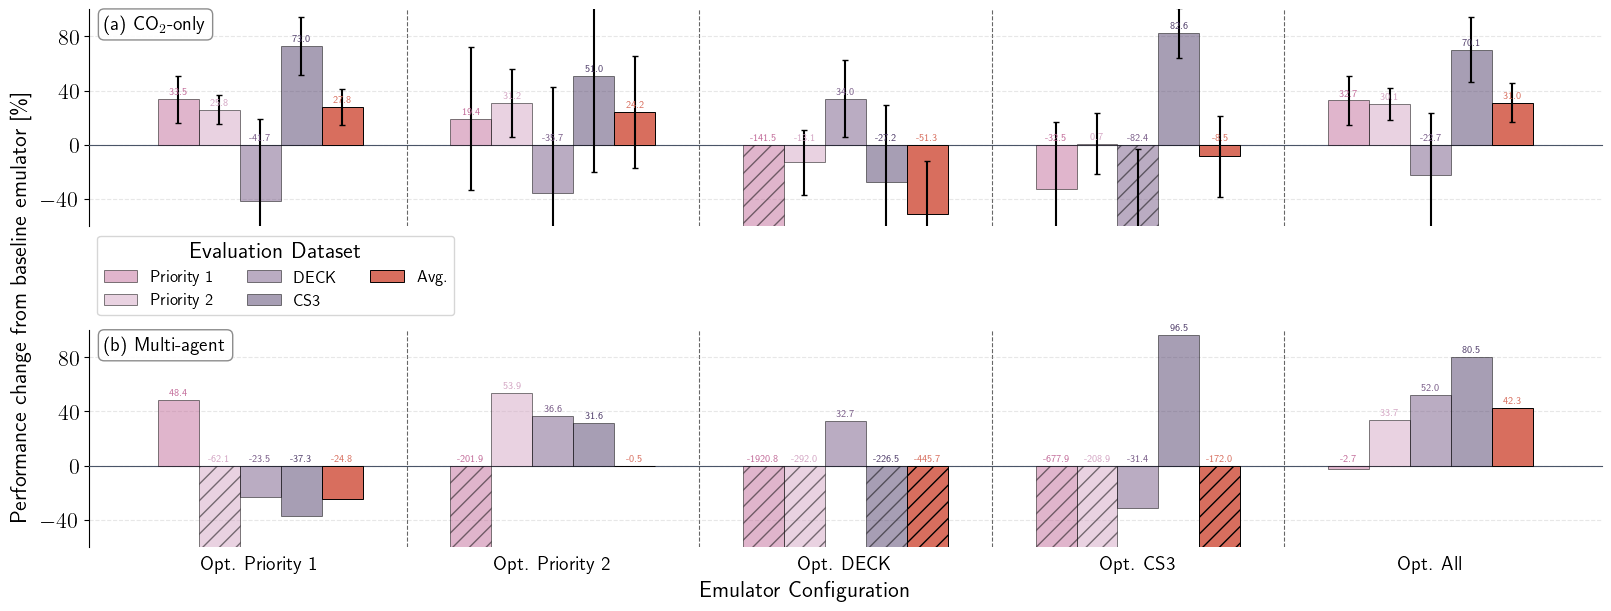

In [12]:
import pickle

with open('data/SI_results/seed_uncertainty/fig4_seed_spread_co2_only.pkl', 'rb') as f:
    _seed_spread = pickle.load(f)

_seed_baseline_results = [_seed_spread[s]['baseline'] for s in sorted(_seed_spread)]
_seed_optimized_results = [_seed_spread[s]['optimal'] for s in sorted(_seed_spread)]

# Multi-agent panel stays single-point (not multi-seeded yet) - reuse load_fig4_data()'s
# default values as panel-1 fallback data; they're only used where seed_*_list is None.
fig4_data_seeded = utils_inverse.load_fig4_data()
utils_plotting.plot_vertical_stacked_bars(
    **fig4_data_seeded, titles=None, save=False,
    seed_baseline_results_list=[_seed_baseline_results, None],
    seed_optimized_results_list=[_seed_optimized_results, None],
)

#### Figure 4, both panels with seed-uncertainty spread (2026-08-13/14, multi-agent Phase 0)

Supersedes the cell above for reporting purposes. The multi-agent panel is no longer a single-point
estimate: `checkpoints/multi/*_subset*.pkl` (the panel's original data source, dated January 2026 -
pre-dating this whole revision effort, and found to have wildly inconsistent per-group update counts,
1,401-20,001) is **deprecated** per user direction. Replaced by `checkpoints/multi_fig4/seed_sweep/`
(`scripts/0c_regenerate_checkpoints_multi_fig4.py`, group set `{tier1, tier2, DECK, CS3, all}` matching
CO2-only's own convention exactly, 1000 updates x 50 seeds, reusing the multi-agent Phase 0
hyperparameters found earlier in this session rather than a fresh search) and
`utils_inverse.regenerate_fig4_all_agents_cache_seed_sweep`
(`data/SI_results/seed_uncertainty/fig4_seed_spread_all_agents.pkl`).

Note this multi-agent panel's `'all'` group differs from `checkpoints/multi_retuned/`'s `'all'`
(used by Stage 6c(b)): here `DAMIP=False, GeoMIP=False` (matching CO2-only, so `'all'` trains on
Tier1+Tier2+DECK+CS3 only) - required for this panel's train_scenarios to mean the same thing as
the CO2-only panel's, since `plot_vertical_stacked_bars` shares one axis across both.

**Two real bugs found and fixed while building this cache** (see REVISIONS.md Session Log for
full detail): (1) `evaluate_optimal_emulator` never threaded `batch_size` to its internal
`train_mlp_sgd` call (hardcoded full-batch) - invisible for CO2-only/single-forcing (all use
`batch_size: null`), but a real mismatch for the multi-agent case (`batch_size: 16`), making the
optimized emulator look 7-27x worse than baseline before the fix. (2) `evaluate_optimal_emulator`'s
`key` argument was dead code (split into unused `k1, k2`, `train_mlp_sgd` silently defaulted to
`PRNGKey(0)`) - caused every seed's fresh retrain to draw identical minibatches, producing spurious
4-30x seed-to-seed variance. Both fixed; re-validated directly against the checkpoints' own
internally-tracked training errors (seeds 0/1/2 matched to within 0.001 NRMSE).

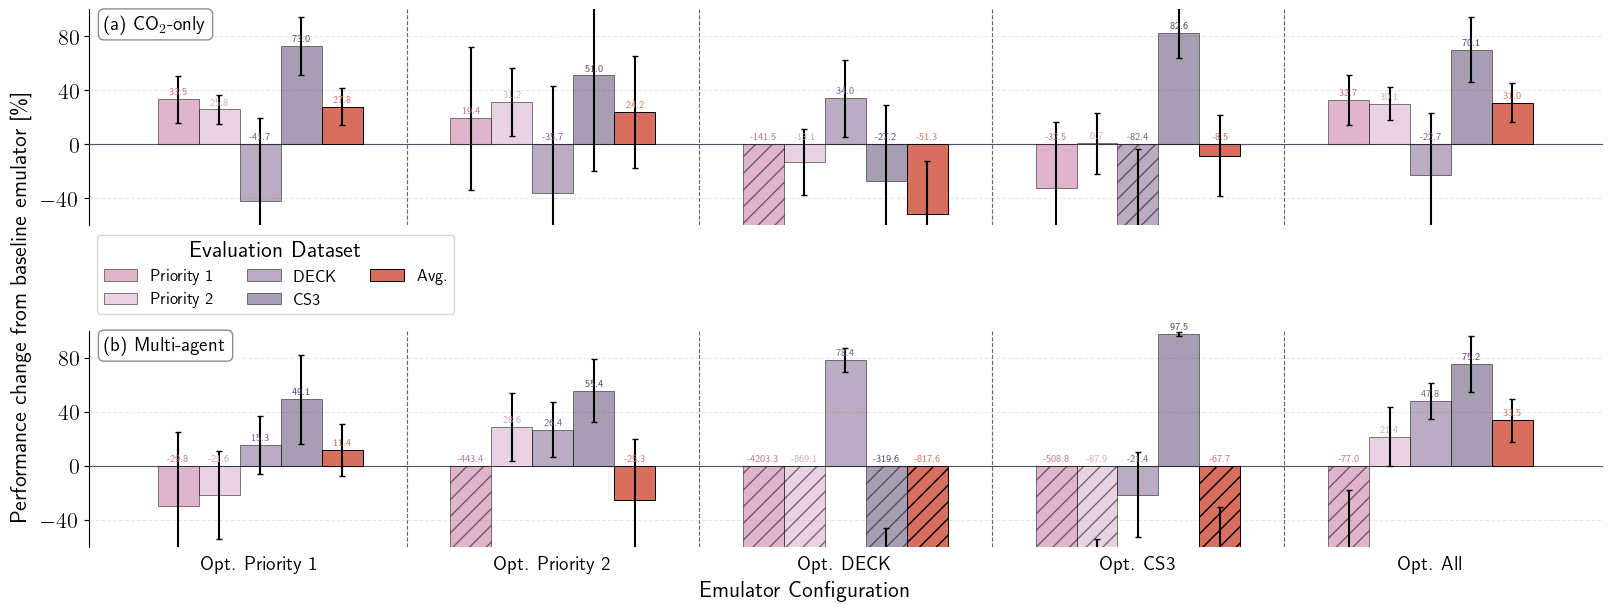

In [13]:
import pickle

with open('data/SI_results/seed_uncertainty/fig4_seed_spread_co2_only.pkl', 'rb') as f:
    _seed_spread_co2 = pickle.load(f)
with open('data/SI_results/seed_uncertainty/fig4_seed_spread_all_agents.pkl', 'rb') as f:
    _seed_spread_multi = pickle.load(f)

_seed_baseline_co2 = [_seed_spread_co2[s]['baseline'] for s in sorted(_seed_spread_co2)]
_seed_optimized_co2 = [_seed_spread_co2[s]['optimal'] for s in sorted(_seed_spread_co2)]
_seed_baseline_multi = [_seed_spread_multi[s]['baseline'] for s in sorted(_seed_spread_multi)]
_seed_optimized_multi = [_seed_spread_multi[s]['optimal'] for s in sorted(_seed_spread_multi)]

fig4_data_seeded_both = utils_inverse.load_fig4_data()
utils_plotting.plot_vertical_stacked_bars(
    **fig4_data_seeded_both, titles=None, save=False,
    seed_baseline_results_list=[_seed_baseline_co2, _seed_baseline_multi],
    seed_optimized_results_list=[_seed_optimized_co2, _seed_optimized_multi],
)

### Figure 5: NRMSE comparison, multi-forcing w/ emissions data

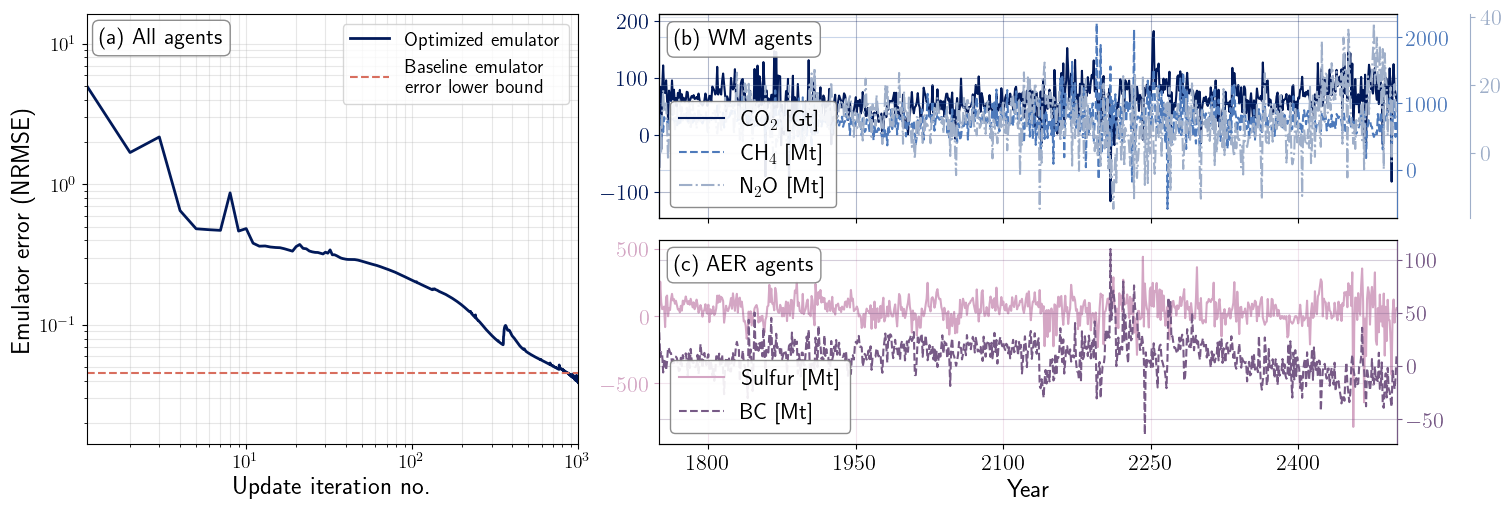

In [14]:
fig5_data = utils_inverse.load_fig5_multi_forcing_data()
utils_plotting.plot_rmse_comparison_multi(fig5_data['results'], fig5_data['baseline_error'], save=False)

### Figure 6: Individual forcing-agent effects (M-GHG / M-aer / G6sulfur)

Reads cached per-agent baseline/optimal-emulator predictions. To refresh those caches after
new checkpoints are produced upstream, run `python scripts/5a_paper_plots.py --figure 6`.

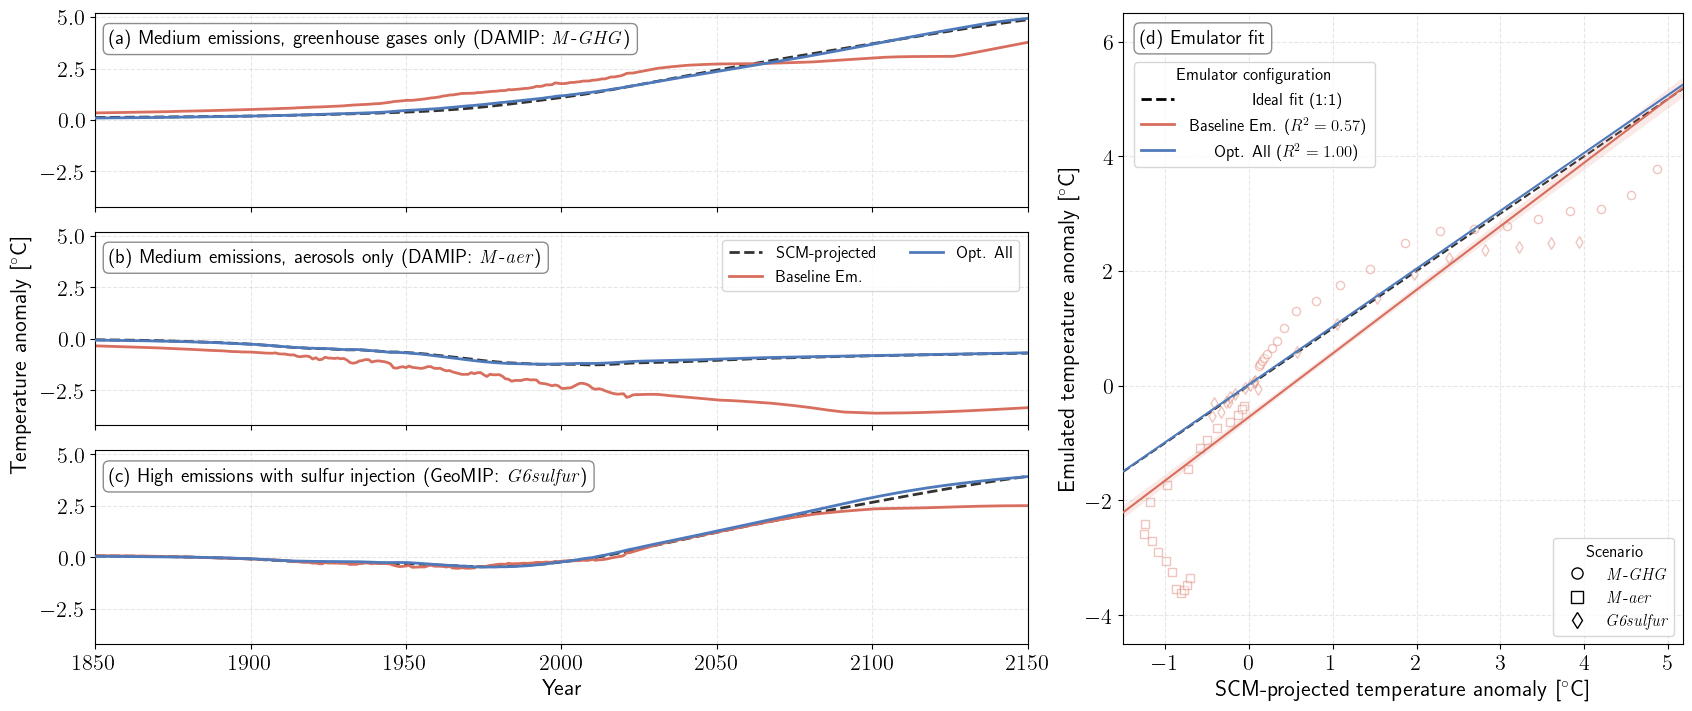

In [15]:
fig6_data = utils_inverse.load_fig6_data()
utils_plotting.plot_individual_effects_summary(**fig6_data, ppt=True, save=False, figname='individual_effects_ppt4')

### Figure 7: EMIC (MESM) zonal-validation summary

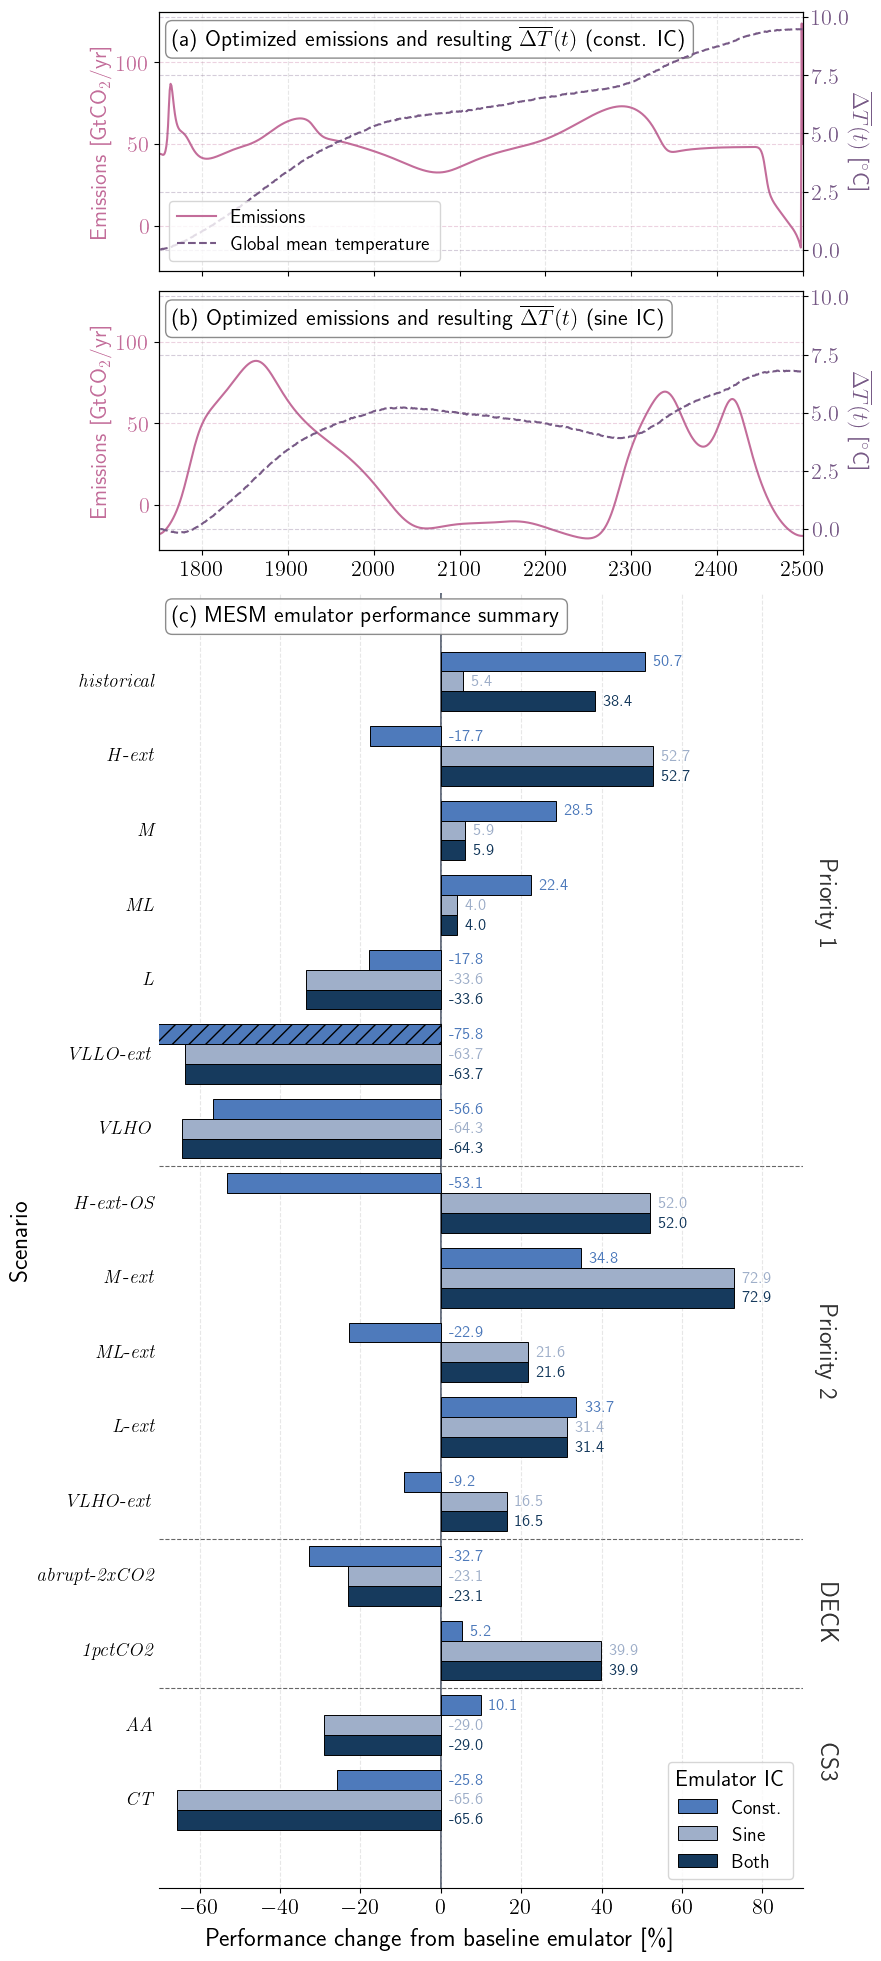

In [16]:
fig7_data = utils_inverse.load_fig7_emic_data()
utils_plotting.plot_scenario_difference_bars2(**fig7_data, save=False, figname='fig07_emic_summary')